# Mini Assignment 1

## Group 25

| Name | Matric No. |
| --------- | -------- |
| Goh Haw Yee | 22105316 |
| Heng Wen Yang | 22115428 |
| Yen Hua Shen | 22086174 |
| Daniel Ang Qi En | 24004519 |
| Saiket Das | 22117847 |

## Task 1: Data Importing and Advanced Cleaning

## Task 1: Data Importing and Advanced Cleaning

### Data Ingestion
First, import the pandas library. Use the read_csv method to read the patient_records.csv file with the delimiter set as ';'.

In [215]:
import pandas as pd

patient_records = pd.read_csv('patient_records.csv', delimiter=';')
patient_records

,patient_id,admission_date,district,hospital_name,ward,age,blood_oxygen_level,heart_rate
0,ID-#08455-X!,2026-10-29,West,Westview Hospital,Observation,45,99,102.0
1,ID-#05101-K!,2026-10-30,Industrial,Industrial Med,ER,44,92,116.0
2,ID-#01656-L!,2026-10-16,Waterfront,Bayview Hospital,Observation,71,98,72.0
3,ID-#07552-R!,2026-10-26,South,South Park Hospital,ER,88,98,81.0
4,**ID_02536?W,2026-10-16,Industrial,Workers Health Center,General,87,96,118.0
...,...,...,...,...,...,...,...,...
8495,ID-#05714-K!,2026-10-30,Central,Metropolis General,ER,82,100,72.0
8496,ID-#06164-B!,2026-10-30,Industrial,Workers Health Center,General,77,81,95.0
8497,ID-#01057-C!,2026-10-24,Industrial,Industrial Med,ER,61,88,101.0
8498,ID-#02384-L!,2026-10-27,East,Eastern Health,ICU,62,83,104.0


Read sensor_data.json using the read_json method from pandas

In [216]:
sensor_data = pd.read_json('sensor_data.json')
sensor_data

,sensor_id,district,metric_type,calibration_status,Day1,Day2,Day3,Day4,Day5,Day6,...,Day21,Day22,Day23,Day24,Day25,Day26,Day27,Day28,Day29,Day30
0,SENS-00998,Waterfront,PM2.5,OK,56.48,56.88,51.16,44.35,41.12,48.43,...,56.62,49.85,None,46.36,49.15,56.51,57.63,52.52,45.09,44.71
1,SENS-01118,West,NO2_ppb,UNKNOWN,24.91,26.9,22.18,18.24,None,19.15,...,25.77,21.84,17.73,None,20.63,24.61,26.26,23.0,19.93,19.43
2,SENS-00795,Industrial,NO2_ppb,OK,41.18,36.11,33.54,28.74,25.59,31.67,...,34.94,33.2,30.11,26.62,32.63,38.9,35.39,34.13,29.1,23.67
3,SENS-00208,North,Chemical_X_ppb,OK,27.64,25.28,23.57,16.81,13.0,21.06,...,29.81,22.28,19.36,14.68,21.43,29.86,25.59,None,19.95,16.27
4,SENS-00323,Central,CO2_ppm,OK,42.63,38.58,36.51,28.33,29.51,33.56,...,38.04,35.05,27.2,None,33.92,42.33,43.9,36.19,31.37,28.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SENS-01599,Waterfront,Chemical_X_ppb,UNKNOWN,50.93,47.62,45.45,37.56,40.7,43.33,...,50.51,44.64,39.14,42.52,43.81,50.61,50.49,46.25,38.91,41.78
9996,SENS-01062,West,PM2.5,OK,44.17,47.09,42.77,36.47,34.84,41.13,...,49.42,42.04,37.13,35.29,40.78,45.66,45.45,43.4,39.7,32.61
9997,SENS-01025,West,NO2_ppb,UNKNOWN,45.71,47.75,40.69,32.81,35.31,37.18,...,42.3,39.36,32.54,33.78,38.18,46.56,42.13,39.99,36.4,34.18
9998,SENS-00263,South,PM2.5,NEEDS_CALIBRATION,56.2,52.09,49.69,45.56,39.66,47.48,...,56.35,48.8,43.74,42.82,48.42,51.38,55.65,51.07,44.3,45.77


Read the hospital_capacity.xlsx file by using pd.ExcelFile and identify the sheets in the file. Then, parse each sheet using a for-loop and append each dataframe into a list. Finally, use pd.concat to merge all the dataframes into one singular dataframe.

In [217]:
hospital_excel = pd.ExcelFile('hospital_capacity.xlsx')
hospital_excel.sheet_names

['Central', 'North', 'South', 'East', 'West', 'Industrial', 'Waterfront']

In [218]:
hospital_list = []
for sheet in hospital_excel.sheet_names:
    df_district = hospital_excel.parse(sheet)
    df_district['district'] = sheet
    hospital_list.append(df_district)

all_hospitals = pd.concat(hospital_list, ignore_index=True)
all_hospitals

,Hospital_Name,Shift,Total_Beds,Available_Beds,Staff_Count,district
0,Metropolis General,Morning,269.0,84.0,81.0,Central
1,Metropolis General,Evening,325.0,86.0,75.0,Central
2,Metropolis General,Night,383.0,114.0,90.0,Central
3,Central Care,Morning,241.0,108.0,73.0,Central
4,Central Care,Evening,368.0,42.0,100.0,Central
5,Central Care,Night,354.0,85.0,65.0,Central
6,Metropolis General,Audit_Error,NaN,NaN,NaN,Central
7,Northern Medical,Morning,329.0,48.0,97.0,North
8,Northern Medical,Evening,367.0,114.0,63.0,North
9,Northern Medical,Night,343.0,82.0,75.0,North


### Data Cleaning
For all DataFrames, first coerce any erratic entries such as dashes (-) in numeric columns using *pd.to_numeric()* with the *coerce* argument to force these values to be **NaN**. Then, diagnose the missing data using *.info()* and *.isnull().any()* and clean the data according to the data types. Perform additional data cleaning methods according to the DataFrame itself.

#### patient_records.csv

In [219]:
patient_records['blood_oxygen_level'] = pd.to_numeric(patient_records['blood_oxygen_level'], errors='coerce')
patient_records['age'] = pd.to_numeric(patient_records['age'], errors='coerce')

patient_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          8500 non-null   object 
 1   admission_date      8500 non-null   object 
 2   district            8500 non-null   object 
 3   hospital_name       8500 non-null   object 
 4   ward                8500 non-null   object 
 5   age                 8063 non-null   float64
 6   blood_oxygen_level  8169 non-null   float64
 7   heart_rate          8267 non-null   float64
dtypes: float64(3), object(5)
memory usage: 531.4+ KB


In [220]:
patient_records[patient_records.isnull().any(axis=1)]

,patient_id,admission_date,district,hospital_name,ward,age,blood_oxygen_level,heart_rate
9,ID-#01744-P!,2026-10-21,Industrial,Workers Health Center,ICU,NaN,84.0,88.0
28,ID-#05285-P!,2026-10-23,Central,Metropolis General,ER,NaN,97.0,77.0
57,ID-#05202-Q!,2026-10-05,North,Northside Clinic,ICU,84.0,NaN,104.0
59,ID-#01438-G!,2026-10-13,West,Westview Hospital,ICU,82.0,93.0,NaN
60,ID-#03465-D!,2026-10-26,North,Northern Medical,General,40.0,98.0,NaN
...,...,...,...,...,...,...,...,...
8470,ID-#02958-D!,2026-10-23,Central,Metropolis General,ER,NaN,97.0,96.0
8474,ID-#04681-T!,2026-10-21,East,Eastern Health,ER,20.0,NaN,106.0
8479,ID-#05238-W!,2026-10-07,Central,Metropolis General,ICU,28.0,NaN,84.0
8483,ID-#04973-P!,2026-10-06,North,Northside Clinic,ER,71.0,93.0,NaN


Fill in the missing numerical **heart_rate**, **blood_oxygen_level** and **age** values using the *.median()* method

In [221]:
patient_records['heart_rate'] = patient_records['heart_rate'].fillna(patient_records['heart_rate'].median())
patient_records['blood_oxygen_level'] = patient_records['blood_oxygen_level'].fillna(patient_records['blood_oxygen_level'].median())
patient_records['age'] = patient_records['age'].fillna(patient_records['age'].median())

patient_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          8500 non-null   object 
 1   admission_date      8500 non-null   object 
 2   district            8500 non-null   object 
 3   hospital_name       8500 non-null   object 
 4   ward                8500 non-null   object 
 5   age                 8500 non-null   float64
 6   blood_oxygen_level  8500 non-null   float64
 7   heart_rate          8500 non-null   float64
dtypes: float64(3), object(5)
memory usage: 531.4+ KB


Replace the **patient_id** values by extracting the numeric part of the ID using *.replace()*. The part to be replaced is represented by a regex, **\D** which means any character that is not a digit is replaced. The value to be replaced is empty. Therefore, the expression strips all characters in the **patient_id** values that is not a number. The regex parameter is set to True to use a regex to find the values that will be replaced.

In [222]:
patient_records['patient_id'] = patient_records['patient_id'].replace(r'\D', '', regex=True)
patient_records

,patient_id,admission_date,district,hospital_name,ward,age,blood_oxygen_level,heart_rate
0,08455,2026-10-29,West,Westview Hospital,Observation,45.0,99.0,102.0
1,05101,2026-10-30,Industrial,Industrial Med,ER,44.0,92.0,116.0
2,01656,2026-10-16,Waterfront,Bayview Hospital,Observation,71.0,98.0,72.0
3,07552,2026-10-26,South,South Park Hospital,ER,88.0,98.0,81.0
4,02536,2026-10-16,Industrial,Workers Health Center,General,87.0,96.0,118.0
...,...,...,...,...,...,...,...,...
8495,05714,2026-10-30,Central,Metropolis General,ER,82.0,100.0,72.0
8496,06164,2026-10-30,Industrial,Workers Health Center,General,77.0,81.0,95.0
8497,01057,2026-10-24,Industrial,Industrial Med,ER,61.0,88.0,101.0
8498,02384,2026-10-27,East,Eastern Health,ICU,62.0,83.0,104.0


Convert categorical string data **district** and **ward** to the *category* data type and convert **age** to *int64* type.

In [223]:
patient_records['district'] = patient_records['district'].astype('category')
patient_records['ward'] = patient_records['ward'].astype('category')
patient_records['age'] = patient_records['age'].astype('int64')

patient_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   patient_id          8500 non-null   object  
 1   admission_date      8500 non-null   object  
 2   district            8500 non-null   category
 3   hospital_name       8500 non-null   object  
 4   ward                8500 non-null   category
 5   age                 8500 non-null   int64   
 6   blood_oxygen_level  8500 non-null   float64 
 7   heart_rate          8500 non-null   float64 
dtypes: category(2), float64(2), int64(1), object(3)
memory usage: 415.7+ KB


#### sensor_data.json

In [224]:
sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sensor_id           10000 non-null  object
 1   district            10000 non-null  object
 2   metric_type         10000 non-null  object
 3   calibration_status  10000 non-null  object
 4   Day1                9806 non-null   object
 5   Day2                9794 non-null   object
 6   Day3                9816 non-null   object
 7   Day4                9816 non-null   object
 8   Day5                9806 non-null   object
 9   Day6                9793 non-null   object
 10  Day7                9813 non-null   object
 11  Day8                9802 non-null   object
 12  Day9                9787 non-null   object
 13  Day10               9805 non-null   object
 14  Day11               9810 non-null   object
 15  Day12               9806 non-null   object
 16  Day13               981

Convert all *object* types into numeric types by first selecting all columns with type *object*. Then, apply the *pd.to_numeric()* function along with the *coerce* argument to convert them to numeric values.

In [225]:
sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sensor_id           10000 non-null  object
 1   district            10000 non-null  object
 2   metric_type         10000 non-null  object
 3   calibration_status  10000 non-null  object
 4   Day1                9806 non-null   object
 5   Day2                9794 non-null   object
 6   Day3                9816 non-null   object
 7   Day4                9816 non-null   object
 8   Day5                9806 non-null   object
 9   Day6                9793 non-null   object
 10  Day7                9813 non-null   object
 11  Day8                9802 non-null   object
 12  Day9                9787 non-null   object
 13  Day10               9805 non-null   object
 14  Day11               9810 non-null   object
 15  Day12               9806 non-null   object
 16  Day13               981

In [226]:
day_columns = [col for col in sensor_data.columns if col.startswith('Day')]

for col in day_columns:
    sensor_data[col] = pd.to_numeric(sensor_data[col], errors='coerce')

sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sensor_id           10000 non-null  object 
 1   district            10000 non-null  object 
 2   metric_type         10000 non-null  object 
 3   calibration_status  10000 non-null  object 
 4   Day1                9699 non-null   float64
 5   Day2                9704 non-null   float64
 6   Day3                9706 non-null   float64
 7   Day4                9719 non-null   float64
 8   Day5                9701 non-null   float64
 9   Day6                9694 non-null   float64
 10  Day7                9713 non-null   float64
 11  Day8                9689 non-null   float64
 12  Day9                9693 non-null   float64
 13  Day10               9708 non-null   float64
 14  Day11               9707 non-null   float64
 15  Day12               9705 non-null   float64
 16  Day13

Fill in the missing numerical values using *.median()* method. First select all the numerical columns, then use the method to fill in the missing values.

In [227]:
sensor_day = sensor_long.groupby(['district', 'Day'], as_index=False).agg(
    mean_pollution=('Pollution_Level', 'mean'),
    peak_pollution=('Pollution_Level', 'max')
)

# Check if we have data
print(f"sensor_day shape: {sensor_day.shape}")
print(sensor_day.head())
print(f"peak_pollution range: {sensor_day['peak_pollution'].min()} to {sensor_day['peak_pollution'].max()}")

sensor_day shape: (210, 4)
  district    Day  mean_pollution  peak_pollution
0  Central   Day1       28.677724           58.24
1  Central  Day10       23.419346           48.38
2  Central  Day11       14.506009           47.16
3  Central  Day12       25.787994           48.15
4  Central  Day13       26.140876           54.07
peak_pollution range: 46.73 to 491.4


C:\Users\User\AppData\Local\Temp\ipykernel_46556\447588740.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sensor_day = sensor_long.groupby(['district', 'Day'], as_index=False).agg(


Convert the **district**, **metric_type** and **calibration_status** columns to *category* data types.

In [228]:
sensor_data['district'] = sensor_data['district'].astype('category')
sensor_data['metric_type'] = sensor_data['metric_type'].astype('category')
sensor_data['calibration_status'] = sensor_data['calibration_status'].astype('category')

sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   sensor_id           10000 non-null  object  
 1   district            10000 non-null  category
 2   metric_type         10000 non-null  category
 3   calibration_status  10000 non-null  category
 4   Day1                9699 non-null   float64 
 5   Day2                9704 non-null   float64 
 6   Day3                9706 non-null   float64 
 7   Day4                9719 non-null   float64 
 8   Day5                9701 non-null   float64 
 9   Day6                9694 non-null   float64 
 10  Day7                9713 non-null   float64 
 11  Day8                9689 non-null   float64 
 12  Day9                9693 non-null   float64 
 13  Day10               9708 non-null   float64 
 14  Day11               9707 non-null   float64 
 15  Day12               9705 non-null   f

#### hospital_capacity.xlsx

In [229]:
all_hospitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hospital_Name   37 non-null     object 
 1   Shift           37 non-null     object 
 2   Total_Beds      33 non-null     float64
 3   Available_Beds  33 non-null     float64
 4   Staff_Count     33 non-null     float64
 5   district        37 non-null     object 
dtypes: float64(3), object(3)
memory usage: 1.9+ KB


In [230]:
all_hospitals[all_hospitals.isnull().any(axis=1)]

,Hospital_Name,Shift,Total_Beds,Available_Beds,Staff_Count,district
6,Metropolis General,Audit_Error,NaN,NaN,NaN,Central
22,Eastern Health,Audit_Error,NaN,NaN,NaN,East
32,Workers Health Center,Audit_Error,NaN,NaN,NaN,Industrial
36,Bayview Hospital,Audit_Error,NaN,NaN,NaN,Waterfront


Drop all rows with missing data as they are Audit Errors

In [231]:
all_hospitals = all_hospitals.dropna()
all_hospitals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 35
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hospital_Name   33 non-null     object 
 1   Shift           33 non-null     object 
 2   Total_Beds      33 non-null     float64
 3   Available_Beds  33 non-null     float64
 4   Staff_Count     33 non-null     float64
 5   district        33 non-null     object 
dtypes: float64(3), object(3)
memory usage: 1.8+ KB


Convert **Shift** and **district** column to a *category* data type.

In [232]:
all_hospitals['Shift'] = all_hospitals['Shift'].astype('category')
all_hospitals['district'] = all_hospitals['district'].astype('category')

all_hospitals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 35
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Hospital_Name   33 non-null     object  
 1   Shift           33 non-null     category
 2   Total_Beds      33 non-null     float64 
 3   Available_Beds  33 non-null     float64 
 4   Staff_Count     33 non-null     float64 
 5   district        33 non-null     category
dtypes: category(2), float64(3), object(1)
memory usage: 1.8+ KB


C:\Users\User\AppData\Local\Temp\ipykernel_46556\4008875563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_hospitals['Shift'] = all_hospitals['Shift'].astype('category')
C:\Users\User\AppData\Local\Temp\ipykernel_46556\4008875563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_hospitals['district'] = all_hospitals['district'].astype('category')


## **Task 2: Tidy Data, Reshaping, and Integration**

The original sensor_data dataset is in a wide format, where each column represents a different day.

To resolve this, we use the pd.melt() function to reshape the dataset into a long format.

In [233]:
sensor_long = pd.melt(
    sensor_data,
    id_vars=['sensor_id', 'district', 'metric_type', 'calibration_status'],
    var_name='Day',
    value_name='Pollution_Level'
)

sensor_long

,sensor_id,district,metric_type,calibration_status,Day,Pollution_Level
0,SENS-00998,Waterfront,PM2.5,OK,Day1,56.48
1,SENS-01118,West,NO2_ppb,UNKNOWN,Day1,24.91
2,SENS-00795,Industrial,NO2_ppb,OK,Day1,41.18
3,SENS-00208,North,Chemical_X_ppb,OK,Day1,27.64
4,SENS-00323,Central,CO2_ppm,OK,Day1,42.63
...,...,...,...,...,...,...
299995,SENS-01599,Waterfront,Chemical_X_ppb,UNKNOWN,Day30,41.78
299996,SENS-01062,West,PM2.5,OK,Day30,32.61
299997,SENS-01025,West,NO2_ppb,UNKNOWN,Day30,34.18
299998,SENS-00263,South,PM2.5,NEEDS_CALIBRATION,Day30,45.77


In the hospital dataset, there may be duplicate records for the same hospital due to multiple entries or repeated measurements. To ensure the data is clean, we use the pivot_table() function to aggregate duplicate entries and summarize the data.

In [234]:
hospital_pivot = all_hospitals.pivot_table(
    index=['Hospital_Name', 'district'],
    values=['Total_Beds', 'Available_Beds', 'Staff_Count'],
    aggfunc='mean'
).reset_index()

hospital_pivot

C:\Users\User\AppData\Local\Temp\ipykernel_46556\1473739365.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hospital_pivot = all_hospitals.pivot_table(


,Hospital_Name,district,Available_Beds,Staff_Count,Total_Beds
0,Bayview Hospital,Waterfront,68.000000,74.333333,381.000000
1,Central Care,Central,78.333333,79.333333,321.000000
2,East Point Med,East,2.666667,52.666667,513.333333
3,Eastern Health,East,4.000000,60.333333,468.000000
4,Industrial Med,Industrial,5.333333,55.000000,450.666667
5,Metropolis General,Central,94.666667,82.000000,325.666667
6,Northern Medical,North,81.333333,78.333333,346.333333
7,Northside Clinic,North,64.333333,69.000000,296.000000
8,South Park Hospital,South,73.000000,81.000000,339.666667
9,Westview Hospital,West,75.333333,72.333333,247.333333


Dimension tables were created from the cleaned and reshaped datasets to support structured data integration.

*   The days table was generated by extracting the Day column from the sensor_long dataset and removing duplicates. This ensures a unique list of time from Day1 to Day30
*   The hospital_dim table was created from the aggregated hospital_pivot dataset by selecting the district and Hospital_Name columns, removing duplicate records, and renaming Hospital_Name to hospital_name for consistency with the other dataset

In [235]:
days = sensor_long[["Day"]].drop_duplicates()
hospital_dim = (
    hospital_pivot[["district", "Hospital_Name"]]
    .drop_duplicates()
    .rename(columns={"Hospital_Name": "hospital_name"})
)

A base grid is created by performing a Cartesian product between the hospital_dim and days tables. This generates all possible combinations of hospitals and days, ensuring that every hospital is represented for every day in the dataset.

The columns (district × hospital_name × Day) are set as a multi-level index to uniquely identify each record.

This base grid serves as a reference structure for data integration at Task 3, helping to align datasets consistently and ensuring that no hospital-day combinations are missing in the final merged dataset.

In [236]:
# Base grid: every hospital x every day
base = hospital_dim.merge(days, how="cross")
idx_cols = ["district", "hospital_name", "Day"]
base_idx = base.set_index(idx_cols).index

print(base_idx)

MultiIndex([('Waterfront',      'Bayview Hospital',  'Day1'),
            ('Waterfront',      'Bayview Hospital',  'Day2'),
            ('Waterfront',      'Bayview Hospital',  'Day3'),
            ('Waterfront',      'Bayview Hospital',  'Day4'),
            ('Waterfront',      'Bayview Hospital',  'Day5'),
            ('Waterfront',      'Bayview Hospital',  'Day6'),
            ('Waterfront',      'Bayview Hospital',  'Day7'),
            ('Waterfront',      'Bayview Hospital',  'Day8'),
            ('Waterfront',      'Bayview Hospital',  'Day9'),
            ('Waterfront',      'Bayview Hospital', 'Day10'),
            ...
            ('Industrial', 'Workers Health Center', 'Day21'),
            ('Industrial', 'Workers Health Center', 'Day22'),
            ('Industrial', 'Workers Health Center', 'Day23'),
            ('Industrial', 'Workers Health Center', 'Day24'),
            ('Industrial', 'Workers Health Center', 'Day25'),
            ('Industrial', 'Workers Health Center', 'D

The data is grouped by district and Day, and two summary statistics are aggregated:

*   mean_pollution: the average pollution level for each district on each day
*   peak_pollution: the maximum pollution level recorded for each district on each day


In [237]:
# --- Sensor block (district-day) ---
sensor_day = (
    sensor_long.groupby(["district", "Day"], as_index=False)
    .agg(
        mean_pollution=("Pollution_Level", "mean"),
        peak_pollution=("Pollution_Level", "max")
    )
)

sensor_day

C:\Users\User\AppData\Local\Temp\ipykernel_46556\362241118.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sensor_long.groupby(["district", "Day"], as_index=False)


,district,Day,mean_pollution,peak_pollution
0,Central,Day1,28.677724,58.24
1,Central,Day10,23.419346,48.38
2,Central,Day11,14.506009,47.16
3,Central,Day12,25.787994,48.15
4,Central,Day13,26.140876,54.07
...,...,...,...,...
205,West,Day5,21.179857,47.54
206,West,Day6,23.606275,49.24
207,West,Day7,30.637275,56.09
208,West,Day8,28.131312,59.64


The aggregated sensor data (previous block) is merged with the base hospital-day grid (base) to assign district-level pollution statistics to each hospital.

*   The merge is performed on district and Day, ensuring that each hospital inherits the corresponding sensor statistics for its district and day.
*   A left join is used so that all hospital-day combinations in the base grid are preserved, even if some sensor values are missing.

The resulting dataset is then:
*   Indexed using district, hospital_name, and Day
*   Reindexed to match the full base grid (base_idx) to maintain consistency and alignment


In [238]:
# Broadcast sensor stats to each hospital in same district/day
sensor_block = (
    base[["district", "hospital_name", "Day"]]
    .merge(sensor_day, on=["district", "Day"], how="left")
    .set_index(idx_cols)
    .reindex(base_idx)
)

sensor_block

mean_pollution  peak_pollution
district   hospital_name         Day                                  
Waterfront Bayview Hospital      Day1        29.068264           57.88
                                 Day2        27.108946           57.88
                                 Day3        23.862909           51.16
                                 Day4        17.132938           47.58
                                 Day5        19.502498           47.43
...                                                ...             ...
Industrial Workers Health Center Day26      133.486456          483.24
                                 Day27      135.506033          485.81
                                 Day28      136.280268          491.40
                                 Day29      131.239716          478.52
                                 Day30      127.508466          486.64

[330 rows x 2 columns]

*   The admission_date column is first converted into a datetime format, and a new Day column is derived based on the day of the month, adjusted so that the dataset starts from Day1 (2026-10-02).
*   Records outside the valid date range (2026-10-02 to 2026-10-31) are filtered out to ensure consistency.
*   The data is then grouped by district, hospital_name, and Day, and the number of patients (patient_count) is computed for each group
*   Finally, the grouped data is reindexed using the base hospital-day grid (base_idx), ensuring that all possible hospital-day combinations are included




In [239]:
# --- Patient block (district-hospital-day) ---
patient_tmp = patient_records.copy()
patient_tmp["admission_date"] = pd.to_datetime(patient_tmp["admission_date"], errors="coerce")
# Minus 1 because admission_date starts at 2026-10-02
patient_tmp["Day"] = "Day" + (patient_tmp["admission_date"].dt.day - 1).astype("Int64").astype(str)

# admission_date starts at 2026-10-02 and ends at 2026-10-31
patient_tmp = patient_tmp[patient_tmp["admission_date"].dt.day.between(2, 31, inclusive="both")]

grouped = patient_tmp.groupby(["district", "hospital_name", "Day"]).agg(
    patient_count=("patient_id", "count")
)

# as_index defaults true - the keys used in groupby will become an index in the returned df
# district, hospital_name, day

patient_block = (
    patient_tmp.groupby(["district", "hospital_name", "Day"])
    .agg(patient_count=("patient_id", "count"))
    .reindex(base_idx)
)

patient_block

C:\Users\User\AppData\Local\Temp\ipykernel_46556\2504362168.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = patient_tmp.groupby(["district", "hospital_name", "Day"]).agg(
C:\Users\User\AppData\Local\Temp\ipykernel_46556\2504362168.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_tmp.groupby(["district", "hospital_name", "Day"])


patient_count
district   hospital_name         Day                 
Waterfront Bayview Hospital      Day1              20
                                 Day2              26
                                 Day3              32
                                 Day4              26
                                 Day5              27
...                                               ...
Industrial Workers Health Center Day26             11
                                 Day27              8
                                 Day28             13
                                 Day29             11
                                 Day30             17

[330 rows x 1 columns]

Hospital capacity data is prepared and aligned with the hospital-day base grid to ensure each record includes relevant capacity information.



*   The hospital_pivot dataset is first standardized by renaming Hospital_Name to hospital_name for consistency.
*   The data is then merged with the base hospital-day grid using district and hospital_name as keys.


*   A left join is used to attach capacity attributes to each hospital-day combination (Total_Beds, Available_Beds, Staff_Count)
*   Since capacity data is static at the hospital level, these values are repeated across all days for each hospital.
*   The result is indexed using district, hospital_name, and Day, and reindexed to align with the base grid (base_idx).


In [240]:
# --- Capacity block (district-hospital), repeated by day via base ---
cap = hospital_pivot.rename(columns={"Hospital_Name": "hospital_name"})
capacity_block = (
    base[["district", "hospital_name", "Day"]]
    .merge(
        cap[["district", "hospital_name", "Total_Beds", "Available_Beds", "Staff_Count"]],
        on=["district", "hospital_name"],
        how="left"
    )
    .set_index(idx_cols)
    .reindex(base_idx)
)

capacity_block

Total_Beds  Available_Beds  \
district   hospital_name         Day                                 
Waterfront Bayview Hospital      Day1        381.0            68.0   
                                 Day2        381.0            68.0   
                                 Day3        381.0            68.0   
                                 Day4        381.0            68.0   
                                 Day5        381.0            68.0   
...                                            ...             ...   
Industrial Workers Health Center Day26       437.0             2.0   
                                 Day27       437.0             2.0   
                                 Day28       437.0             2.0   
                                 Day29       437.0             2.0   
                                 Day30       437.0             2.0   

                                        Staff_Count  
district   hospital_name         Day                 
Waterfront Bayview Hospital      Day1     74.333333  
                                 Day2     74.333333  
                                 Day3     74.333333  
                                 Day4     74.333333  
                                 Day5     74.333333  
...                                             ...  
Industrial Workers Health Center Day26    50.000000  
                                 Day27    50.000000  
                                 Day28    50.000000  
                                 Day29    50.000000  
                                 Day30    50.000000  

[330 rows x 3 columns]

The processed datasets from the three sources (hospital capacity, patient records, sensor data) are integrated into a single dataset

In [241]:
# --- Final concat of all 3 sources ---
integrated_concat = pd.concat(
    [
        capacity_block[["Total_Beds", "Available_Beds", "Staff_Count"]],
        patient_block[["patient_count"]],
        sensor_block[["mean_pollution", "peak_pollution"]],
    ],
    axis=1,
    join="inner"
).reset_index()

# Clean remaining gaps
integrated_concat["patient_count"] = integrated_concat["patient_count"].fillna(0).astype(int)

integrated_concat

,district,hospital_name,Day,Total_Beds,Available_Beds,Staff_Count,patient_count,mean_pollution,peak_pollution
0,Waterfront,Bayview Hospital,Day1,381.0,68.0,74.333333,20,29.068264,57.88
1,Waterfront,Bayview Hospital,Day2,381.0,68.0,74.333333,26,27.108946,57.88
2,Waterfront,Bayview Hospital,Day3,381.0,68.0,74.333333,32,23.862909,51.16
3,Waterfront,Bayview Hospital,Day4,381.0,68.0,74.333333,26,17.132938,47.58
4,Waterfront,Bayview Hospital,Day5,381.0,68.0,74.333333,27,19.502498,47.43
...,...,...,...,...,...,...,...,...,...
325,Industrial,Workers Health Center,Day26,437.0,2.0,50.000000,11,133.486456,483.24
326,Industrial,Workers Health Center,Day27,437.0,2.0,50.000000,8,135.506033,485.81
327,Industrial,Workers Health Center,Day28,437.0,2.0,50.000000,13,136.280268,491.40
328,Industrial,Workers Health Center,Day29,437.0,2.0,50.000000,11,131.239716,478.52


## Task 3: Object-Oriented Analysis & Complex Grouping

In [242]:
import numpy as np

### The OutbreakAnalyzer class function:

_init__(patient_path, sensor_path, hospital_path)
Initializes the class with dataset paths and automatically loads all files.

_load_datasets()
Reads patient_records.csv, sensor_data.json, and all sheets in hospital_capacity.xlsx into DataFrames using exception handling (try-except-finally) for robustness.

set_integrated_data(integrated_df)
Accepts the integrated Task 2 DataFrame and validates required columns before Task 3 analysis.

crisis_severity(total_patients, hospital_capacity, peak_pollution)
Static helper function that computes the custom Crisis Severity Score:
Severity = (Total Patients / Hospital Capacity) x Peak Pollution
Includes safeguards for invalid or zero capacity.

task3_grouped_analysis()
Performs .groupby(['district', 'hospital_name']) aggregation, applies built-in metrics and lambda-based metrics, computes severity score, and returns a ranked high-risk hospital table.

In [243]:
class OutbreakAnalyzer:
    def __init__(self, patient_path, sensor_path, hospital_path):
        # Save file paths so the class can reload data if needed
        self.patient_path = patient_path
        self.sensor_path = sensor_path
        self.hospital_path = hospital_path

        # Placeholders for loaded and processed data
        self.patient_records = None
        self.sensor_data = None
        self.all_hospitals = None
        self.integrated_data = None
        self.task3_summary = None

        # Load datasets immediately when object is created
        self._load_datasets()

    def _load_datasets(self):
        try:
            # Read patient CSV with semicolon delimiter
            self.patient_records = pd.read_csv(self.patient_path, delimiter=";")

            # Read sensor JSON
            self.sensor_data = pd.read_json(self.sensor_path)

            # Read all hospital sheets and combine into one dataframe
            xls = pd.ExcelFile(self.hospital_path)
            frames = []
            for sheet in xls.sheet_names:
                temp = xls.parse(sheet)
                temp["district"] = sheet
                frames.append(temp)

            # Concatenate all district sheets into one table
            self.all_hospitals = pd.concat(frames, ignore_index=True)

        except FileNotFoundError as e:
            print(f"File not found: {e}")
            raise
        except Exception as e:
            print(f"Unexpected loading error: {e}")
            raise
        finally:
            print("Dataset loading attempt completed.")

    def set_integrated_data(self, integrated_df):
        required = {
            "district",
            "hospital_name",
            "Day",
            "patient_count",
            "Total_Beds",
            "Available_Beds",
            "Staff_Count",
            "mean_pollution",
            "peak_pollution",
        }
        missing = required.difference(set(integrated_df.columns))
        if missing:
            raise ValueError(f"Missing required columns: {sorted(missing)}")

        self.integrated_data = integrated_df.copy()

    @staticmethod
    def crisis_severity(total_patients, hospital_capacity, peak_pollution):
        # Custom formula:
        # Severity = (Total Patients / Hospital Capacity) x Peak Pollution
        try:
            if pd.isna(hospital_capacity) or hospital_capacity == 0:
                return np.nan
            return (total_patients / hospital_capacity) * peak_pollution
        except ZeroDivisionError:
            return np.nan
        except Exception:
            return np.nan
        finally:
            pass

    def grouped_analysis(self):
        if self.integrated_data is None:
            raise ValueError("Integrated data is not set. Use set_integrated_data first.")

        df = self.integrated_data.copy()

        # Group by district and hospital as required
        grouped = df.groupby(["district", "hospital_name"]).agg(
            # Built in aggregations
            total_patients=("patient_count", "sum"),
            max_daily_patients=("patient_count", "max"),
            avg_daily_patients=("patient_count", "mean"),
            p95_daily_patients=("patient_count", lambda s: s.quantile(0.95)),
            hospital_capacity=("Available_Beds", "min"),
            total_beds=("Total_Beds", "max"),
            avg_staff=("Staff_Count", "mean"),
            peak_pollution=("peak_pollution", "max"),
            avg_pollution=("mean_pollution", "mean"),
        ).reset_index()

        # Apply custom severity function row by row
        grouped["crisis_severity_score"] = grouped.apply(
            lambda r: OutbreakAnalyzer.crisis_severity(
                r["total_patients"],
                r["hospital_capacity"],
                r["peak_pollution"],
            ),
            axis=1,
        )

        # Sort highest risk hospitals
        grouped = grouped.sort_values("crisis_severity_score", ascending=False).reset_index(drop=True)
        self.task3_summary = grouped
        return grouped

### Create analyzer object and load all datasets

In [244]:
analyzer = OutbreakAnalyzer(
    patient_path="patient_records.csv",
    sensor_path="sensor_data.json",
    hospital_path="hospital_capacity.xlsx",
)

Dataset loading attempt completed.


### Use integrated_concat from Task 2

In [245]:
analyzer.set_integrated_data(integrated_concat)

### Run grouped analysis and show top rows

In [246]:
task3_result = analyzer.grouped_analysis()
task3_result.head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_46556\1035442102.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["district", "hospital_name"]).agg(


,district,hospital_name,total_patients,max_daily_patients,avg_daily_patients,p95_daily_patients,hospital_capacity,total_beds,avg_staff,peak_pollution,avg_pollution,crisis_severity_score
0,Industrial,Workers Health Center,616,55.0,20.533333,46.55,2.000000,437.000000,50.000000,491.40,81.230460,151351.200000
1,East,East Point Med,599,52.0,19.966667,45.85,2.666667,513.333333,52.666667,271.54,41.614954,60994.672500
2,Industrial,Industrial Med,584,55.0,19.466667,46.30,5.333333,450.666667,55.000000,491.40,81.230460,53808.300000
3,East,Eastern Health,587,49.0,19.566667,42.55,4.000000,468.000000,60.333333,271.54,41.614954,39848.495000
4,Waterfront,Bayview Hospital,1240,95.0,41.333333,89.40,68.000000,381.000000,74.333333,59.34,24.874731,1082.082353
5,South,South Park Hospital,1210,103.0,40.333333,91.65,73.000000,339.666667,81.000000,59.72,24.991241,989.879452
6,West,Westview Hospital,1223,97.0,40.766667,90.55,75.333333,247.333333,72.333333,59.64,24.470320,968.226372
7,North,Northside Clinic,617,57.0,20.566667,45.55,64.333333,296.000000,69.000000,59.64,24.821202,571.987772
8,North,Northern Medical,630,54.0,21.000000,50.65,81.333333,346.333333,78.333333,59.64,24.821202,461.965574
9,Central,Central Care,595,51.0,19.833333,47.65,78.333333,321.000000,79.333333,59.39,25.128027,451.111277


## **Task 4: Advanced Visualization & Exporting**
The objective is to create a visual dashboard to identify the anomaly source and determine which hospitals are at risk of capacity overload.

### Import visualization libraries

In [247]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np

### SubTask 1: Create a comprehensive dashboard using plt.subplots() (e.g., a 2x2 grid). (Matplotlib Subplot)
#### Histogram: peak_pollution from integrated_concat (daily data)
#### Boxplot: patient_count by district from integrated_concat

### Data Availability Checking
Check what's in integrated_concat (daily data)

In [248]:
print("=== integrated_concat (daily data) ===")
print(f"Shape: {integrated_concat.shape}")
print(f"Columns: {list(integrated_concat.columns)}")
print()

=== integrated_concat (daily data) ===
Shape: (330, 9)
Columns: ['district', 'hospital_name', 'Day', 'Total_Beds', 'Available_Beds', 'Staff_Count', 'patient_count', 'mean_pollution', 'peak_pollution']



Check what's in task3_result (aggregated hospital data)

In [249]:
print("=== task3_result (hospital-level data) ===")
print(f"Shape: {task3_result.shape}")
print(f"Columns: {list(task3_result.columns)}")
print()

=== task3_result (hospital-level data) ===
Shape: (77, 12)
Columns: ['district', 'hospital_name', 'total_patients', 'max_daily_patients', 'avg_daily_patients', 'p95_daily_patients', 'hospital_capacity', 'total_beds', 'avg_staff', 'peak_pollution', 'avg_pollution', 'crisis_severity_score']



In [250]:
# use integrated_concat for histogram and box plot
# use task3_result for bubble chart and 3D scatter plot
print("Data is ready for visualization.")

Data is ready for visualization.


### matplotlib Subplots - 2x2 Dashboard

C:\Users\User\AppData\Local\Temp\ipykernel_46556\836207533.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(patient_by_district, labels=district_list)


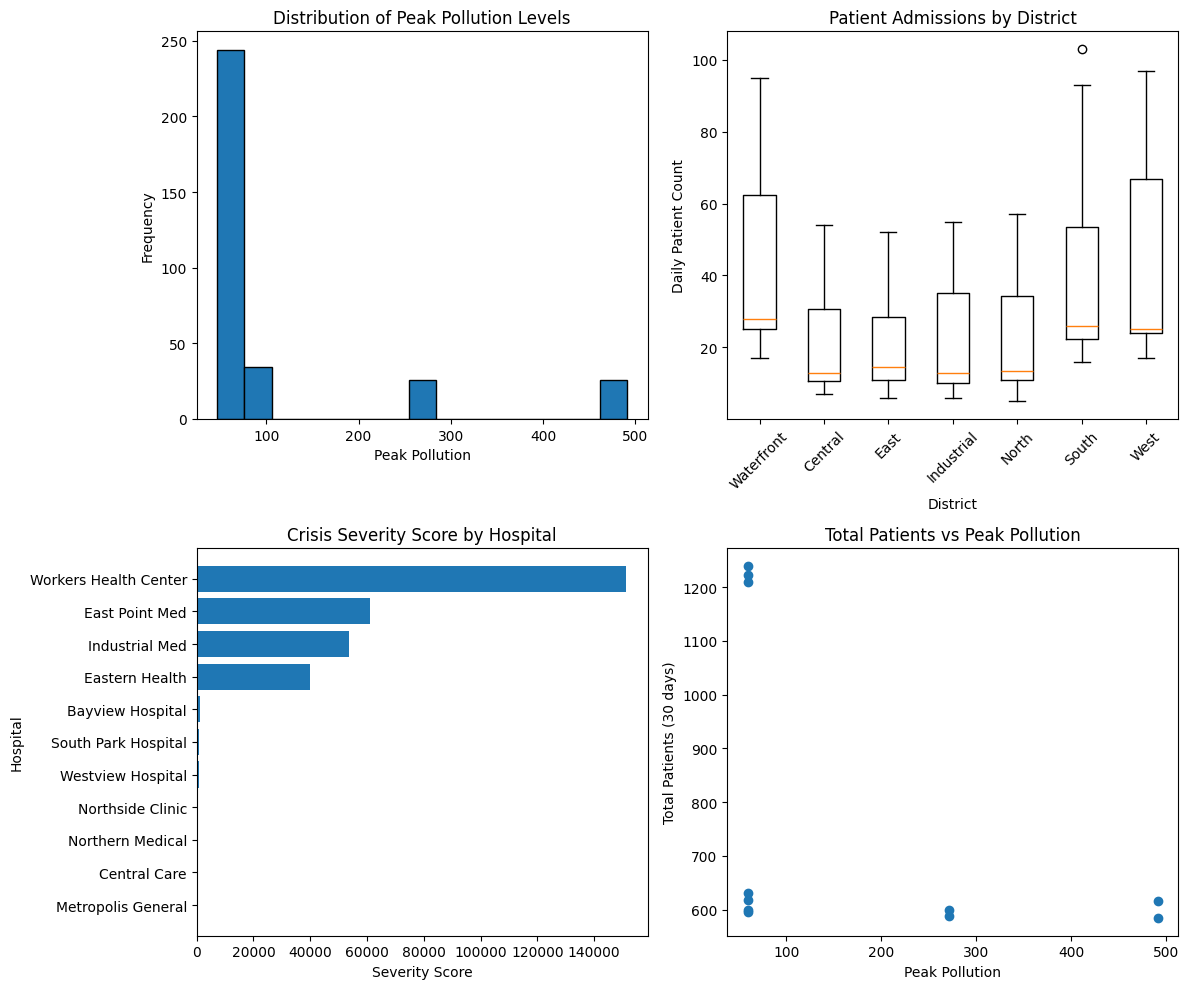

In [257]:
# This is the 2x2 dashboard for histogram and boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
### Plot 1: Histogram to observe the frequency distribution of the pollution levels (use the bins argument).
axes[0, 0].hist(integrated_concat['peak_pollution'], bins=15, edgecolor='black')
axes[0, 0].set_title('Distribution of Peak Pollution Levels')
axes[0, 0].set_xlabel('Peak Pollution')
axes[0, 0].set_ylabel('Frequency')
### Plot 2: Boxplot to detect outliers in patient admissions across districts
district_list = integrated_concat['district'].unique()
patient_by_district = []
for district in district_list:
    data = integrated_concat[integrated_concat['district'] == district]['patient_count']
    patient_by_district.append(data)

axes[0, 1].boxplot(patient_by_district, labels=district_list)
axes[0, 1].set_title('Patient Admissions by District')
axes[0, 1].set_xlabel('District')
axes[0, 1].set_ylabel('Daily Patient Count')
axes[0, 1].tick_params(axis='x', rotation=45)
### Plot 3: Bar Chart of Crisis Severity by Hospital (Bottom-Left)
sorted_hospitals = task3_result.sort_values('crisis_severity_score', ascending=True) # make worst hospitals appear at the top
axes[1, 0].barh(sorted_hospitals['hospital_name'], sorted_hospitals['crisis_severity_score'])
axes[1, 0].set_title('Crisis Severity Score by Hospital')
axes[1, 0].set_xlabel('Severity Score')
axes[1, 0].set_ylabel('Hospital')
### Plot 4: Scatter Plot - Patients vs Pollution (Bottom-Right)
axes[1, 1].scatter(task3_result['peak_pollution'], task3_result['total_patients'])
axes[1, 1].set_title('Total Patients vs Peak Pollution')
axes[1, 1].set_xlabel('Peak Pollution')
axes[1, 1].set_ylabel('Total Patients (30 days)')
### Display the Dashboard
plt.tight_layout()
plt.show()

### Bubble Chart (where marker sizes = severity) to emulate advanced analytics
#### Remove any rows with NaN in crisis_severity_score

In [253]:
task3_result_clean = task3_result.dropna(subset=['crisis_severity_score'])

print(f"Original rows: {len(task3_result)}")
print(f"Rows after dropping NaN: {len(task3_result_clean)}")
print(f"NaN count in crisis_severity_score: {task3_result['crisis_severity_score'].isna().sum()}")

Original rows: 77
Rows after dropping NaN: 11
NaN count in crisis_severity_score: 66


In [254]:
fig = px.scatter(
    task3_result_clean,
    x='peak_pollution',
    y='total_patients',
    size='crisis_severity_score',
    color='district',
    hover_name='hospital_name',
    title='Hospital Crisis Severity (Bigger Bubble = Worse)'
)

fig.show()

### 3D Scatter Plot (px.scatter_3d) plotting Pollution Level, Patient Count, and Hospital Capacity to identify the exact district where the anomaly originated.

In [255]:
fig = px.scatter_3d(
    task3_result,
    x='peak_pollution',
    y='total_patients',
    z='hospital_capacity',
    color='district',
    hover_name='hospital_name',
    title='3D Plot: Pollution vs Patients vs Available Beds'
)

fig.show()

## **Finally, Export Data to Pickle File**

In [256]:
task3_result.to_pickle('metropolis_x_clean_data.pkl')

print("File saved: metropolis_x_clean_data.pkl")
print(f"Shape: {task3_result.shape}")
print(f"Columns: {list(task3_result.columns)}")

File saved: metropolis_x_clean_data.pkl
Shape: (77, 12)
Columns: ['district', 'hospital_name', 'total_patients', 'max_daily_patients', 'avg_daily_patients', 'p95_daily_patients', 'hospital_capacity', 'total_beds', 'avg_staff', 'peak_pollution', 'avg_pollution', 'crisis_severity_score']
